# FER-2013: ANN Baseline (No Stabilisation)
This notebook trains a simple ANN baseline on FER-2013 and creates a shared train/val/test split for comparison with a CNN.

## 1. Imports and Configuration
This section imports libraries, sets seeds, and defines file paths for the dataset and saved splits.

In [18]:
# --- Standard library imports ---
import os
import pathlib
import random

# --- Third-party imports ---
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Reproducibility / Fairness
# -----------------------------
# Fix seeds so that splitting and training are repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Paths / Data Settings
# -----------------------------
# We try a few common dataset locations (helpful if you run from repo root vs an assessment folder).
CANDIDATE_DATA_DIRS = [
    pathlib.Path("./data/fer-2013"),
    pathlib.Path("./Assessments/Assessment-2-Machine-Learning/data/fer-2013"),
]

# Pick the first candidate that looks correct.
DATA_DIR = None
for candidate in CANDIDATE_DATA_DIRS:
    if (candidate / "train").exists() and (candidate / "test").exists():
        DATA_DIR = candidate
        break

# If we still didn't find it, fail with a helpful message.
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find FER-2013 dataset folder. Tried:\n"
        + "\n".join(str(c.resolve()) for c in CANDIDATE_DATA_DIRS)
        + "\n\nExpected structure: <DATA_DIR>/train/<class folders> and <DATA_DIR>/test/<class folders>."
    )

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# Saved split file so both ANN and CNN use identical arrays.
SPLITS_PATH = pathlib.Path("./fer-2013_splits.npz")

# FER-2013 images are 48x48 grayscale.
IMG_SIZE = (48, 48)

# Training hyperparameters (keep these consistent across models for a fair comparison).
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3

print("Using DATA_DIR:", DATA_DIR.resolve())
print("TRAIN_DIR:", TRAIN_DIR.resolve())
print("TEST_DIR :", TEST_DIR.resolve())
print("SPLITS_PATH:", SPLITS_PATH.resolve())


Using DATA_DIR: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\data\fer-2013
TRAIN_DIR: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\data\fer-2013\train
TEST_DIR : C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\data\fer-2013\test
SPLITS_PATH: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\fer-2013_splits.npz


## 2. Load Training Images (for Split Creation)
This section loads the training folder into memory so we can create a stratified train/validation split.

In [19]:
# Load all images from train/ with labels inferred from folder names.
# batch_size=None gives an unbatched dataset (one (image, label) at a time),
# which makes it easy to convert to NumPy arrays for stratified splitting.
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",          # infer labels from subfolder names
    label_mode="int",           # int class indices
    color_mode="grayscale",     # FER is grayscale
    image_size=IMG_SIZE,        # force 48x48
    batch_size=None,            # unbatched for splitting
    shuffle=True,
    seed=SEED
)

# Save class names in the order TensorFlow assigns them.
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Convert the tf.data dataset to NumPy arrays (X_train_all, y_train_all).
X_train_all, y_train_all = [], []
for x, y in train_ds:
    X_train_all.append(x.numpy())
    y_train_all.append(y.numpy())

X_train_all = np.stack(X_train_all)          # (N, 48, 48, 1)
y_train_all = np.array(y_train_all).astype(int)

print("Loaded training samples:", X_train_all.shape[0])


Found 28709 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Loaded training samples: 28709


## 3. Create/Load Shared Splits
This section creates a stratified train/val split from the training set and loads the test set untouched (or loads an existing saved split).

In [20]:
# If splits already exist, we reuse them to guarantee fairness across reruns/notebooks.
if SPLITS_PATH.exists():
    print("Found existing split file. Loading:", SPLITS_PATH.resolve())
else:
    print("No split file found. Creating a new stratified train/val split and loading test set...")

    # -----------------------------
    # 1) Split train -> train/val
    # -----------------------------
    # Stratify to preserve class proportions in both sets.
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.20,
        random_state=SEED,
        stratify=y_train_all
    )

    # -----------------------------
    # 2) Load the official test set (untouched)
    # -----------------------------
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=None,
        shuffle=False
    )

    X_test, y_test = [], []
    for x, y in test_ds:
        X_test.append(x.numpy())
        y_test.append(y.numpy())

    X_test = np.stack(X_test)
    y_test = np.array(y_test).astype(int)

    # -----------------------------
    # 3) Normalise pixels to [0, 1]
    # -----------------------------
    # This is standard for neural networks and does NOT change model architecture.
    X_train = X_train.astype("float32") / 255.0
    X_val   = X_val.astype("float32")   / 255.0
    X_test  = X_test.astype("float32")  / 255.0

    # -----------------------------
    # 4) Save splits so CNN can use the exact same arrays
    # -----------------------------
    np.savez(
        SPLITS_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        class_names=np.array(class_names)
    )
    print("Saved split file to:", SPLITS_PATH.resolve())

# Load splits into memory (regardless of whether we created them or not).
splits = np.load(SPLITS_PATH, allow_pickle=True)

X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val     = splits["X_val"], splits["y_val"]
X_test, y_test   = splits["X_test"], splits["y_test"]
class_names      = splits["class_names"].tolist()
num_classes      = len(class_names)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Test label counts:", dict(zip(*np.unique(y_test, return_counts=True))))


Found existing split file. Loading: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\fer-2013_splits.npz
Train: (22967, 48, 48, 1) Val: (5742, 48, 48, 1) Test: (7178, 48, 48, 1)
Test label counts: {np.int64(0): np.int64(958), np.int64(1): np.int64(111), np.int64(2): np.int64(1024), np.int64(3): np.int64(1774), np.int64(4): np.int64(1233), np.int64(5): np.int64(1247), np.int64(6): np.int64(831)}


## 4. Compute Class Weights (Baseline)
This section computes balanced class weights to reduce the impact of class imbalance during training.

In [21]:
# Compute class weights from TRAIN labels only (no leakage).
# Note: this is the *baseline* behaviour (no capping).
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Keras expects a dict {class_index: weight}
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0265957446808511), 1: np.float64(9.401146131805158), 2: np.float64(1.0012206286237413), 3: np.float64(0.5684338184338185), 4: np.float64(0.8260322255790534), 5: np.float64(0.849120082815735), 6: np.float64(1.2932597556168703)}


## 5. Flatten Images for Baseline ANN Input
This section reshapes each 48x48 image (2304 pixels) into a 1D vector for the fully-connected model.

In [22]:
# Flatten images to vectors: 48*48 = 2304 features per sample.
X_train_f = X_train.reshape(len(X_train), -1)
X_val_f   = X_val.reshape(len(X_val), -1)
X_test_f  = X_test.reshape(len(X_test), -1)

print("Flattened shapes:", X_train_f.shape, X_val_f.shape, X_test_f.shape)


Flattened shapes: (22967, 2304) (5742, 2304) (7178, 2304)


## 6. Build and Compile Baseline ANN
This section defines a simple ANN without Normalization/BatchNorm to act as the baseline comparison.

In [23]:
# --- Baseline ANN ---
# This model is intentionally simple:
# - Dense(512) -> Dropout -> Dense(256) -> Dropout -> Softmax
# It does NOT include BatchNorm or a learned Normalization layer (those are stabilisation improvements).
ann = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_f.shape[1],)),

    # First dense block
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.40),

    # Second dense block
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.40),

    # Output layer
    tf.keras.layers.Dense(num_classes, activation="softmax")
], name="ANN_Baseline")

# Compile with Adam optimizer and a standard multi-class loss.
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann.summary()


Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,287 (5.01 MB)

 Trainable params: 1,313,287 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train Baseline ANN
This section trains the baseline ANN using early stopping and class weights.

In [24]:
# EarlyStopping helps prevent overfitting and stops training when validation performance stalls.
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]

# Train the model.
history = ann.fit(
    X_train_f, y_train,
    validation_data=(X_val_f, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,  # baseline uses raw class weights (no capping)
    verbose=1
)


Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1075 - loss: 1.9957 - val_accuracy: 0.1698 - val_loss: 1.9416
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0965 - loss: 1.9462 - val_accuracy: 0.1682 - val_loss: 1.9451
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1008 - loss: 1.9462 - val_accuracy: 0.1674 - val_loss: 1.9450
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1262 - loss: 1.9465 - val_accuracy: 0.1679 - val_loss: 1.9421
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1385 - loss: 1.9463 - val_accuracy: 0.2518 - val_loss: 1.9432
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1342 - loss: 1.9462 - val_accuracy: 0.1682 - val_loss: 1.9418
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1544 - loss: 1.9467 - val_accuracy: 0.2515 - val_loss: 1.9415
Epoch 8/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1521 - loss: 1.9461 - val_accuracy: 0.

## 8. Plot & Save Training Curves
This cell generates the learning curves and saves them as PDFs

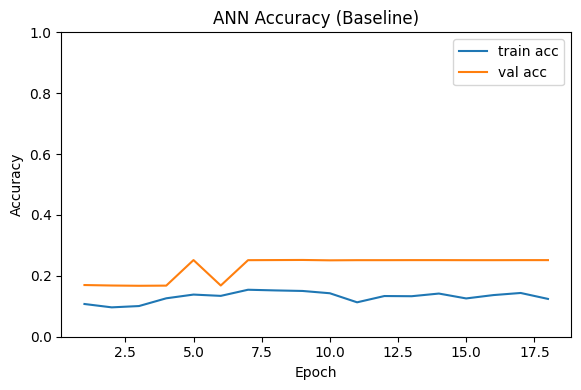

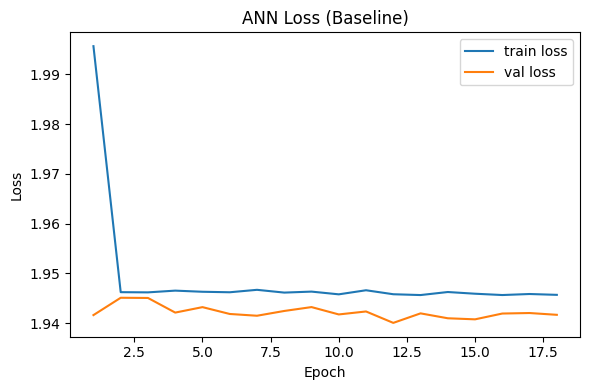

Saved PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\ann\ann_baseline_accuracy.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\ann\ann_baseline_loss.pdf


In [25]:
import pathlib
import matplotlib.pyplot as plt

OUT_DIR = pathlib.Path("results/plots/ann/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "ANN"
FILE_PREFIX = "ann_baseline"

# Work out how many epochs actually ran (EarlyStopping may stop early)
epochs_ran = range(1, len(history.history.get("loss", [])) + 1)

# -------- Accuracy plot --------
plt.figure(figsize=(6, 4))

# Pull accuracy arrays safely (in case keys ever differ)
train_acc = history.history.get("accuracy", None)
val_acc = history.history.get("val_accuracy", None)

if train_acc is not None:
    plt.plot(epochs_ran, train_acc, label="train acc")
if val_acc is not None:
    plt.plot(epochs_ran, val_acc, label="val acc")

plt.title(f"{TITLE_PREFIX} Accuracy (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)

# Save BEFORE show (so the saved PDF matches what you see)
acc_pdf_path = OUT_DIR / f"{FILE_PREFIX}_accuracy.pdf"
plt.savefig(acc_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

# -------- Loss plot --------
plt.figure(figsize=(6, 4))

train_loss = history.history.get("loss", None)
val_loss = history.history.get("val_loss", None)

if train_loss is not None:
    plt.plot(epochs_ran, train_loss, label="train loss")
if val_loss is not None:
    plt.plot(epochs_ran, val_loss, label="val loss")

plt.title(f"{TITLE_PREFIX} Loss (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_pdf_path = OUT_DIR / f"{FILE_PREFIX}_loss.pdf"
plt.savefig(loss_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved PDFs to:")
print(" -", acc_pdf_path.resolve())
print(" -", loss_pdf_path.resolve())


## 9. Evaluate Baseline ANN & Show Confusion Matrices
This section reports test performance and produces two confusion matrices for later comparison.

ANN Test Accuracy: 0.2471

Classification Report (ANN Baseline):
              precision    recall  f1-score   support

       angry       0.50      0.00      0.00       958
     disgust       0.00      0.00      0.00       111
        fear       0.00      0.00      0.00      1024
       happy       0.25      1.00      0.40      1774
     neutral       0.00      0.00      0.00      1233
         sad       0.00      0.00      0.00      1247
    surprise       0.00      0.00      0.00       831

    accuracy                           0.25      7178
   macro avg       0.11      0.14      0.06      7178
weighted avg       0.13      0.25      0.10      7178



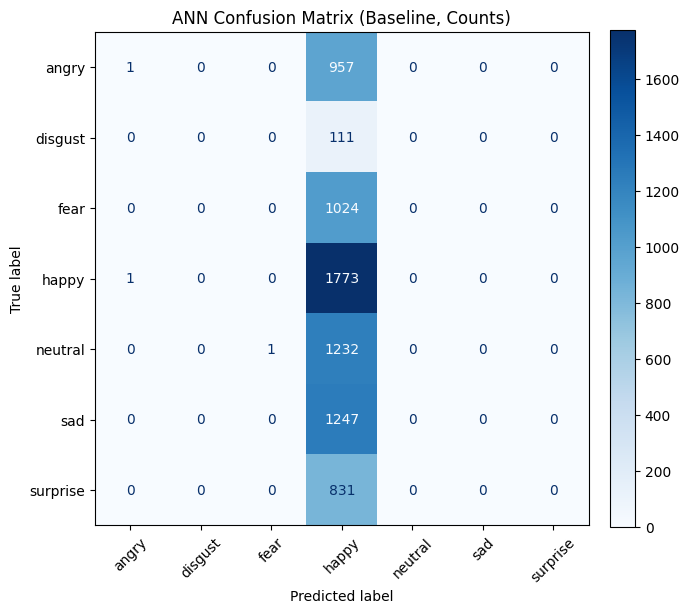

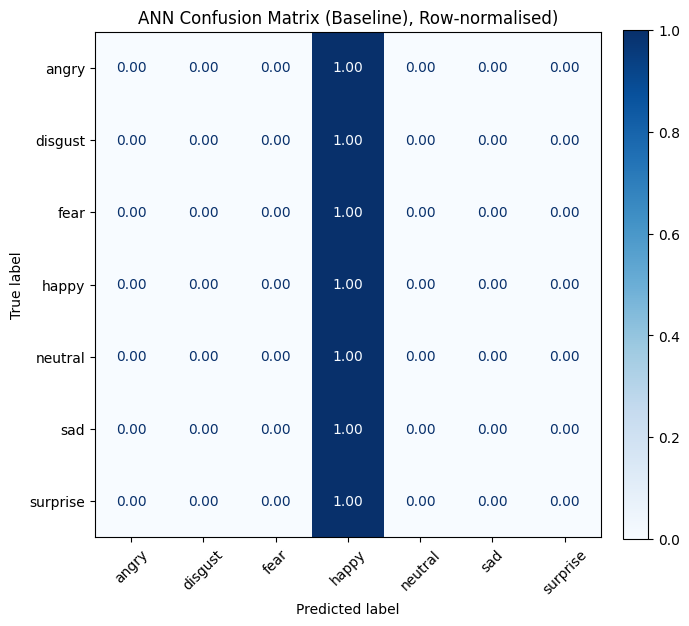


Saved confusion matrix PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\ann\ann_baseline_cm_counts.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\ann\ann_baseline_cm_row_normalised.pdf


In [ ]:
# --- Evaluate ANN + Confusion Matrices (Counts + Row-normalised) + Save as PDFs ---
# This cell:
# 1) Evaluates on the held-out test set
# 2) Generates predictions + classification report
# 3) Plots confusion matrix (counts)
# 4) Plots confusion matrix (row-normalised)
# 5) Saves both confusion matrices as PDFs

import pathlib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1) Evaluate on held-out test set
# -----------------------------
# The test set is never used during training/validation.
test_loss, test_acc = ann.evaluate(X_test_f, y_test, verbose=0)
print(f"ANN Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 2) Predict labels (argmax over softmax probabilities)
# -----------------------------
y_pred = np.argmax(ann.predict(X_test_f, verbose=0), axis=1)

# -----------------------------
# 3) Classification report (precision/recall/F1)
# -----------------------------
print("\nClassification Report (ANN Baseline):")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# -----------------------------
# 4) Prepare output folder and filenames
# -----------------------------
OUT_DIR = pathlib.Path("results/confusion-matrices/ann/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "ANN"
FILE_PREFIX = "ann_baseline"

# -----------------------------
# 5) Confusion Matrix (Counts)
# -----------------------------
cm_counts = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 7))

# Plot the matrix WITHOUT a colourbar (we'll add our own so it matches height)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_counts, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)

# Manually add a colourbar that is tied to the matrix axis (same height)
im = ax.images[0]  # the heatmap image
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Baseline, Counts)")
fig.tight_layout()

counts_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_counts.pdf"
fig.savefig(counts_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)


# -----------------------------
# 6) Confusion Matrix (Row-normalised)
# -----------------------------
# Each row sums to 1.00, so you can compare per-class behaviour fairly.
cm_row = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 7))

# Plot WITHOUT colourbar first
disp = ConfusionMatrixDisplay(confusion_matrix=cm_row, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)

# Add matching-height colourbar
im = ax.images[0]
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Baseline), Row-normalised)")
fig.tight_layout()

row_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_row_normalised.pdf"
fig.savefig(row_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)


# -----------------------------
# 7) Confirm saved files
# -----------------------------
print("\nSaved confusion matrix PDFs to:")
print(" -", counts_pdf_path.resolve())
print(" -", row_pdf_path.resolve())
